In [ ]:
"""
MobileNetV3-Large fine-tuning baseline on HAM10000 — matched to the DINOv2 run.

Same splits (loaded from splits.csv), same colour constancy, same weight cap,
same label smoothing, same eval. The ONLY variable is the model, so the
comparison is honest.

Colab, GPU runtime. Paste into cells at the CELL markers.

Note on the recipe: this is a *proper* MobileNet fine-tune, not the one from
the blueprint. Differences that matter:
  - keeps the 1280-unit hidden layer (blueprint's Linear(960,7) throws it away)
  - unfreezes the WHOLE backbone in stage 2, not the last 2 blocks
    (dermoscopy is far from ImageNet; partial unfreezing underfits badly)
  - weight cap 2.0, matching what the DINOv2 sweep found optimal
"""

"\nMobileNetV3-Large fine-tuning baseline on HAM10000 — matched to the DINOv2 run.\n\nSame splits (loaded from splits.csv), same colour constancy, same weight cap,\nsame label smoothing, same eval. The ONLY variable is the model, so the\ncomparison is honest.\n\nColab, GPU runtime. Paste into cells at the CELL markers.\n\nNote on the recipe: this is a *proper* MobileNet fine-tune, not the one from\nthe blueprint. Differences that matter:\n  - keeps the 1280-unit hidden layer (blueprint's Linear(960,7) throws it away)\n  - unfreezes the WHOLE backbone in stage 2, not the last 2 blocks\n    (dermoscopy is far from ImageNet; partial unfreezing underfits badly)\n  - weight cap 2.0, matching what the DINOv2 sweep found optimal\n"

In [ ]:

# ============================================================ CELL 1: setup
import os, glob, time, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import kagglehub
DATA = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("dataset:", DATA)

SEED = 42
OUT = "/content/drive/MyDrive/amsdds/mobilenetv4299342"
CACHE = "/content/ham_cache"          # LOCAL disk — Drive is far too slow for
os.makedirs(OUT, exist_ok=True)       # thousands of small image reads
os.makedirs(CACHE, exist_ok=True)

IMG_SIZE = 224
BATCH = 32
WEIGHT_CAP = 2.0
USE_COLOR_CONSTANCY = True
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(SEED); np.random.seed(SEED)
print("device:", DEVICE)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
dataset: /kaggle/input/skin-cancer-mnist-ham10000
device: cuda


In [ ]:

# ============================================ CELL 2: reuse the SAME splits
src = {os.path.splitext(os.path.basename(p))[0]: p
       for p in glob.glob(f"{DATA}/**/*.jpg", recursive=True)}

splits_csv = f"{OUT}/splits.csv"
if os.path.exists(splits_csv):
    df = pd.read_csv(splits_csv)
    print("loaded existing splits — comparison is apples-to-apples")
else:
    from sklearn.model_selection import StratifiedGroupKFold
    meta = glob.glob(f"{DATA}/**/HAM10000_metadata*.csv", recursive=True)[0]
    df = pd.read_csv(meta)
    df["y"] = df.dx.map({c: i for i, c in enumerate(sorted(df.dx.unique()))})
    sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)
    fold = np.zeros(len(df), dtype=int)
    for f, (_, idx) in enumerate(sgkf.split(df, df.y, groups=df.lesion_id)):
        fold[idx] = f
    df["split"] = np.where(fold == 0, "test", np.where(fold == 1, "val", "train"))
    df.to_csv(splits_csv, index=False)
    print("regenerated splits")

CLASSES = sorted(df.dx.unique())
df["y"] = df.dx.map({c: i for i, c in enumerate(CLASSES)})
df["src"] = df.image_id.map(src)
df["path"] = df.image_id.map(lambda i: f"{CACHE}/{i}.jpg")
assert df.src.isna().sum() == 0, "some images not found"
print(df.split.value_counts().to_dict())



loaded existing splits — comparison is apples-to-apples
{'train': 7116, 'val': 1458, 'test': 1441}


In [ ]:

# ================================ CELL 3: one-time preprocessed image cache
# Colour constancy + resize done ONCE to local disk. Without this, every epoch
# redoes the numpy power ops on 600x450 images and the CPU starves the GPU.
def shades_of_gray(arr, power=6):
    a = arr.astype(np.float32)
    vec = np.power(np.mean(np.power(a, power), axis=(0, 1)), 1.0 / power)
    vec = vec / (np.sqrt(np.sum(vec ** 2)) + 1e-8)
    return np.clip(a / (vec * np.sqrt(3) + 1e-8), 0, 255).astype(np.uint8)


def build_one(row):
    dst = row.path
    if os.path.exists(dst):
        return
    img = Image.open(row.src).convert("RGB")
    w, h = img.size
    s = 256 / min(w, h)
    img = img.resize((round(w * s), round(h * s)), Image.BICUBIC)
    if USE_COLOR_CONSTANCY:
        img = Image.fromarray(shades_of_gray(np.array(img)))
    img.save(dst, quality=95)


need = sum(not os.path.exists(p) for p in df.path)
if need:
    from concurrent.futures import ThreadPoolExecutor
    t0 = time.time()
    with ThreadPoolExecutor(8) as ex:
        list(ex.map(build_one, [r for r in df.itertuples()]))
    print(f"cached {need} images in {time.time()-t0:.0f}s")
else:
    print("image cache already built")



image cache already built


In [ ]:

# ============================================ CELL 4: datasets + transforms
MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

train_tf = T.Compose([
    T.RandomResizedCrop(299, scale=(0.65, 1.0), ratio=(0.85, 1.18)),
    T.RandomHorizontalFlip(), T.RandomVerticalFlip(),
    T.RandomApply([T.RandomRotation(30)], p=0.5),
    T.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.25, hue=0.03),
    T.RandomApply([T.GaussianBlur(5, sigma=(0.1, 1.5))], p=0.25),
    T.ToTensor(), T.Normalize(MEAN, STD),
])
eval_tf = T.Compose([
    T.Resize(324), T.CenterCrop(299),
    T.ToTensor(), T.Normalize(MEAN, STD),
])
# ============================================================
# Metadata preprocessing
# ============================================================

# IMPORTANT:
# Calculate these using TRAIN ONLY.
tr, va, te = (df[df.split == s] for s in ("train", "val", "test"))
age_mean = tr["age"].mean()
age_std = tr["age"].std()

if pd.isna(age_std) or age_std == 0:
    age_std = 1.0

# Categories learned from TRAIN
sex_categories = sorted(
    tr["sex"].dropna().astype(str).unique().tolist()
)

location_categories = sorted(
    tr["localization"].dropna().astype(str).unique().tolist()
)

print("Age mean:", age_mean)
print("Age std:", age_std)
print("Sex categories:", sex_categories)
print("Localization categories:", location_categories)


class HAM(Dataset):
    def __init__(self, frame, tf):
        self.f = frame.reset_index(drop=True); self.tf = tf

    def __len__(self):
        return len(self.f)

    def __getitem__(self, i):
        r = self.f.iloc[i]
        img=self.tf(Image.open(r.path).convert("RGB"))
        age=r.age
        if pd.isna(age):
            age = age_mean

        age = (
            float(age) - float(age_mean)
        ) / float(age_std)
        sex = (
            str(r.sex)
            if not pd.isna(r.sex)
            else None
        )
        sex_vec = [
            float(sex == category)
            for category in sex_categories
        ]
        location = (
            str(r.localization)
            if not pd.isna(r.localization)
            else None
        )

        location_vec = [
            float(location == category)
            for category in location_categories
        ]
        metadata = torch.tensor(
            [age] + sex_vec + location_vec,
            dtype=torch.float32
        )

        return img, metadata, int(r.y)
METADATA_DIM = (
    1
    + len(sex_categories)
    + len(location_categories)
)

print("Metadata dimension:", METADATA_DIM)

dl_tr = DataLoader(HAM(tr, train_tf), BATCH, shuffle=True, num_workers=4,
                   pin_memory=True, drop_last=True, persistent_workers=True)
dl_va = DataLoader(HAM(va, eval_tf), 64, num_workers=4, pin_memory=True)
dl_te = DataLoader(HAM(te, eval_tf), 64, num_workers=4, pin_memory=True)



Age mean: 51.53242899533701
Age std: 16.952723340294664
Sex categories: ['female', 'male', 'unknown']
Localization categories: ['abdomen', 'acral', 'back', 'chest', 'ear', 'face', 'foot', 'genital', 'hand', 'lower extremity', 'neck', 'scalp', 'trunk', 'unknown', 'upper extremity']
Metadata dimension: 19


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:

# ==================================================== CELL 5: model + loss
# ============================================================
# CELL 5: multimodal MobileNetV3 + metadata
# ============================================================

class MultiModalMobileNetV3(nn.Module):

    def __init__(
        self,
        metadata_dim,
        num_classes
    ):
        super().__init__()

        # ------------------------------------------------
        # IMAGE BRANCH
        # ------------------------------------------------

        self.image_model = mobilenet_v3_large(
            weights=MobileNet_V3_Large_Weights.IMAGENET1K_V2
        )

        # Remove final classification layer
        # Keep the 1280-dimensional representation
        self.image_model.classifier[3] = nn.Identity()

        IMAGE_DIM = 1280

        # ------------------------------------------------
        # METADATA BRANCH
        # ------------------------------------------------

        self.metadata_model = nn.Sequential(
            nn.Linear(metadata_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU()
        )

        METADATA_FEATURES = 32

        # ------------------------------------------------
        # FUSION CLASSIFIER
        # ------------------------------------------------

        self.classifier = nn.Sequential(
            nn.Linear(
                IMAGE_DIM + METADATA_FEATURES,
                128
            ),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, x, metadata):

        # Image representation
        image_features = self.image_model(x)

        # Metadata representation
        metadata_features = self.metadata_model(metadata)

        # Fuse
        fused = torch.cat(
            [image_features, metadata_features],
            dim=1
        )

        # Final prediction
        return self.classifier(fused)


model = MultiModalMobileNetV3(
    metadata_dim=METADATA_DIM,
    num_classes=len(CLASSES)
).to(DEVICE)

counts = np.bincount(tr.y.values, minlength=len(CLASSES)).astype(np.float32)
w = 1.0 / np.sqrt(counts)
w = np.clip(w / w.min(), 1.0, WEIGHT_CAP)
print("class weights:", dict(zip(CLASSES, np.round(w, 2))))
lossfn = nn.CrossEntropyLoss(weight=torch.tensor(w).to(DEVICE), label_smoothing=0.05)

scaler = torch.amp.GradScaler("cuda", enabled=DEVICE == "cuda")
from sklearn.metrics import f1_score


@torch.no_grad()
@torch.no_grad()
def evaluate(loader, return_logits=False):

    model.eval()

    L, Y = [], []

    for x, metadata, y in loader:

        x = x.to(
            DEVICE,
            non_blocking=True
        )

        metadata = metadata.to(
            DEVICE,
            non_blocking=True
        )

        with torch.autocast(
            "cuda",
            torch.float16,
            enabled=DEVICE == "cuda"
        ):

            logits = model(
                x,
                metadata
            ).float().cpu()

        L.append(logits)
        Y.append(y)

    L = torch.cat(L)
    Y = torch.cat(Y)

    f1 = f1_score(
        Y.numpy(),
        L.argmax(1).numpy(),
        average="macro"
    )

    return (
        (f1, L, Y)
        if return_logits
        else f1
    )


def run_epochs(n, opt, sched, tag):

    global best_f1, best_state

    for ep in range(n):

        model.train()
        t0 = time.time()

        for x, metadata, y in dl_tr:

            x = x.to(
                DEVICE,
                non_blocking=True
            )

            metadata = metadata.to(
                DEVICE,
                non_blocking=True
            )

            y = y.to(
                DEVICE,
                non_blocking=True
            )

            opt.zero_grad(
                set_to_none=True
            )

            with torch.autocast(
                "cuda",
                torch.float16,
                enabled=DEVICE == "cuda"
            ):

                logits = model(
                    x,
                    metadata
                )

                loss = lossfn(
                    logits,
                    y
                )

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

        sched.step()

        val_f1 = evaluate(dl_va)

        print(
            f"{tag} epoch {ep+1}/{n} "
            f"val_macro_f1={val_f1:.4f} "
            f"time={time.time()-t0:.0f}s"
        )

        if val_f1 > best_f1:

            best_f1 = val_f1

            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }



class weights: {'akiec': np.float32(2.0), 'bcc': np.float32(2.0), 'bkl': np.float32(2.0), 'df': np.float32(2.0), 'mel': np.float32(2.0), 'nv': np.float32(1.0), 'vasc': np.float32(2.0)}


In [ ]:
batch = next(iter(dl_tr))

print(type(batch))
print(len(batch))

for i, item in enumerate(batch):
    print(i, type(item), getattr(item, "shape", None))

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


<class 'list'>
3
0 <class 'torch.Tensor'> torch.Size([32, 3, 299, 299])
1 <class 'torch.Tensor'> torch.Size([32, 19])
2 <class 'torch.Tensor'> torch.Size([32])


In [ ]:
train_ds = HAM(tr, train_tf)
val_ds   = HAM(va, eval_tf)
test_ds  = HAM(te, eval_tf)
sample = train_ds[0]

print("sample length:", len(sample))
print("image type:", type(sample[0]))

if isinstance(sample[0], (list, tuple)):
    print("image list length:", len(sample[0]))
    print("image contents types:", [type(x) for x in sample[0]])

sample length: 3
image type: <class 'torch.Tensor'>


In [ ]:

# ============================================== CELL 6: two-stage fine-tune
best_f1, best_state = -1, None

# Stage 1 — frozen backbone, classifier only
for p in model.image_model.features.parameters():
    p.requires_grad_(False)
opt = torch.optim.AdamW(
    list(model.image_model.classifier.parameters()) +
    list(model.metadata_model.parameters()) +
    list(model.classifier.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)
run_epochs(5, opt, torch.optim.lr_scheduler.CosineAnnealingLR(opt, 5), "S1")

# Stage 2 — unfreeze EVERYTHING, low LR on the backbone
for p in model.image_model.features.parameters():
    p.requires_grad_(True)
EPOCHS2 = 25
opt = torch.optim.AdamW([
    {
        "params": model.image_model.features.parameters(),
        "lr": 1e-4
    },
    {
        "params": model.image_model.classifier.parameters(),
        "lr": 5e-4
    },
    {
        "params": model.metadata_model.parameters(),
        "lr": 5e-4
    },
    {
        "params": model.classifier.parameters(),
        "lr": 5e-4
    },
], weight_decay=1e-4)
run_epochs(EPOCHS2, opt, torch.optim.lr_scheduler.CosineAnnealingLR(opt, EPOCHS2), "S2")

model.load_state_dict(best_state)
print(f"\nbest val macro-F1 {best_f1:.4f}")


S1 epoch 1/5 val_macro_f1=0.4177 time=123s


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


S1 epoch 2/5 val_macro_f1=0.5292 time=114s


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


S1 epoch 3/5 val_macro_f1=0.5736 time=113s


...

S2 epoch 23/25 val_macro_f1=0.7503 time=118s


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


S2 epoch 24/25 val_macro_f1=0.7385 time=118s


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


S2 epoch 25/25 val_macro_f1=0.7389 time=120s

best val macro-F1 0.7555


In [ ]:

# ============================== CELL 7: temperature scaling + test evaluation
_, lv, yv = evaluate(dl_va, return_logits=True)
lv, yv = lv.to(DEVICE), yv.to(DEVICE)
logT = torch.zeros(1, device=DEVICE, requires_grad=True)
topt = torch.optim.LBFGS([logT], lr=0.1, max_iter=60)


def _closure():
    topt.zero_grad()
    l = F.cross_entropy(lv / logT.exp(), yv); l.backward(); return l


topt.step(_closure)
TEMP = float(logT.exp())
print(f"fitted temperature T = {TEMP:.3f}")


def ece(probs, labels, bins=15):
    conf, pred = probs.max(1), probs.argmax(1)
    acc = (pred == labels).astype(np.float32)
    edges = np.linspace(0, 1, bins + 1); e = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum():
            e += m.mean() * abs(acc[m].mean() - conf[m].mean())
    return e


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

_, lt, yt = evaluate(dl_te, return_logits=True)
yt = yt.numpy()
p_raw = F.softmax(lt, 1).numpy()
p_cal = F.softmax(lt / TEMP, 1).numpy()
pred = p_cal.argmax(1)

MB = {"test_acc": accuracy_score(yt, pred),
      "test_macro_f1": f1_score(yt, pred, average="macro"),
      "ece_raw": ece(p_raw, yt), "ece_cal": ece(p_cal, yt),
      "val_macro_f1": best_f1, "temperature": TEMP}

print(f"\ntest accuracy   {MB['test_acc']:.4f}")
print(f"test macro-F1   {MB['test_macro_f1']:.4f}")
print(f"ECE  raw {MB['ece_raw']:.4f}  ->  calibrated {MB['ece_cal']:.4f}")
print("\n", classification_report(yt, pred, target_names=CLASSES, digits=3))
print(pd.DataFrame(confusion_matrix(yt, pred), index=CLASSES, columns=CLASSES))

torch.save(
    {
        "model_state": model.state_dict(),
        "classes": CLASSES,
        "metadata_dim": METADATA_DIM,
        "sex_categories": sex_categories,
        "location_categories": location_categories,
        "age_mean": float(age_mean),
        "age_std": float(age_std),
        "metrics": MB,
        "temperature": TEMP,
    },
    f"{OUT}/multimodal_mobilenetv3.pt"
)

print(
    f"saved to {OUT}/multimodal_mobilenetv3.pt"
)
json.dump({k: float(v) for k, v in MB.items()},
          open(f"{OUT}/metrics_mobilenetv3.json", "w"), indent=2)



/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


fitted temperature T = 0.959


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



test accuracy   0.8446
test macro-F1   0.7077
ECE  raw 0.0456  ->  calibrated 0.0442

               precision    recall  f1-score   support

       akiec      0.500     0.588     0.541        34
         bcc      0.798     0.753     0.775        89
         bkl      0.715     0.732     0.724       168
          df      0.800     0.444     0.571         9
         mel      0.544     0.555     0.549       146
          nv      0.929     0.930     0.930       974
        vasc      1.000     0.762     0.865        21

    accuracy                          0.845      1441
   macro avg      0.755     0.681     0.708      1441
weighted avg      0.847     0.845     0.845      1441

       akiec  bcc  bkl  df  mel   nv  vasc
akiec     20    4    7   0    2    1     0
bcc        5   67    6   1    7    3     0
bkl        8    1  123   0   14   22     0
df         3    0    0   4    0    2     0
mel        2    6   17   0   81   40     0
nv         2    6   19   0   41  906     0
vasc       0  

In [ ]:

# ================================================ CELL 8: side-by-side table
DINO = {"test_acc": 0.8119, "test_macro_f1": 0.6387,
        "ece_raw": 0.0251, "ece_cal": 0.0183, "val_macro_f1": 0.7174}

cmp = pd.DataFrame({
    "MobileNetV3 (fine-tuned)": [MB["test_acc"], MB["test_macro_f1"],
                                 MB["ece_raw"], MB["ece_cal"], MB["val_macro_f1"]],
    "DINOv2 ViT-S (frozen+MLP)": [DINO["test_acc"], DINO["test_macro_f1"],
                                  DINO["ece_raw"], DINO["ece_cal"], DINO["val_macro_f1"]],
}, index=["test accuracy", "test macro-F1", "ECE raw", "ECE calibrated", "val macro-F1"])
print(cmp.round(4))
cmp.to_csv(f"{OUT}/layer1_comparison.csv")

# Per-class melanoma recall is the number that matters clinically — pull it out
mel_i = CLASSES.index("mel")
cm = confusion_matrix(yt, pred)
print(f"\nmelanoma recall: {cm[mel_i, mel_i] / cm[mel_i].sum():.3f}")
print(f"melanoma -> nv misses: {cm[mel_i, CLASSES.index('nv')]}")


                MobileNetV3 (fine-tuned)  DINOv2 ViT-S (frozen+MLP)
test accuracy                     0.8446                     0.8119
test macro-F1                     0.7077                     0.6387
ECE raw                           0.0456                     0.0251
ECE calibrated                    0.0442                     0.0183
val macro-F1                      0.7555                     0.7174

melanoma recall: 0.555
melanoma -> nv misses: 40


In [ ]:
"""
Threshold sweep for the Adaptive Decision Engine (blueprint Section 8.3).

Run in the SAME notebook as the MobileNetV3 script — reuses model, dl_va,
dl_te, CLASSES, TEMP, OUT. If the runtime died, re-run its Cells 1-5 first
(the image cache is on local disk and rebuilds in a few minutes).

Sweeps on VAL only. Test is touched once at the end, for reporting.

The objective is NOT "escalation rate 20-35%". That is a compute-budget
constraint, not a goal. The goal is: of the malignant lesions Layer 1 calls
benign, how many does the gate catch and send to Layer 2? Those are the
failures that hurt someone.
"""


'\nThreshold sweep for the Adaptive Decision Engine (blueprint Section 8.3).\n\nRun in the SAME notebook as the MobileNetV3 script — reuses model, dl_va,\ndl_te, CLASSES, TEMP, OUT. If the runtime died, re-run its Cells 1-5 first\n(the image cache is on local disk and rebuilds in a few minutes).\n\nSweeps on VAL only. Test is touched once at the end, for reporting.\n\nThe objective is NOT "escalation rate 20-35%". That is a compute-budget\nconstraint, not a goal. The goal is: of the malignant lesions Layer 1 calls\nbenign, how many does the gate catch and send to Layer 2? Those are the\nfailures that hurt someone.\n'

In [ ]:

# ==================================================== CELL A: get the logits
import numpy as np, pandas as pd, torch, torch.nn.functional as F, json, os

MALIGNANT = ["mel", "bcc", "akiec"]          # akiec = in-situ SCC, treat as concerning
BENIGN = [c for c in CLASSES if c not in MALIGNANT]
MAL_I = [CLASSES.index(c) for c in MALIGNANT]
BEN_I = [CLASSES.index(c) for c in BENIGN]
print("malignant:", MALIGNANT, "| benign:", BENIGN)


def logits_for(loader):
    _, L, Y = evaluate(loader, return_logits=True)
    return L, Y.numpy()


Lv, yv = logits_for(dl_va)
Lt, yt = logits_for(dl_te)


def conf_entropy(L, temp):
    """Calibrated confidence + entropy normalised by log(n_classes), so the
    threshold is a clean class-count-independent number in [0, 1]."""
    p = F.softmax(L / temp, dim=1).numpy()
    conf = p.max(1)
    ent = -(p * np.log(p + 1e-12)).sum(1) / np.log(len(CLASSES))
    return p, conf, ent


pv, cv, ev = conf_entropy(Lv, TEMP)
pt, ct, et = conf_entropy(Lt, TEMP)
predv, predt = pv.argmax(1), pt.argmax(1)

# A "dangerous miss": truly malignant, predicted benign.
dang_v = np.isin(yv, MAL_I) & np.isin(predv, BEN_I)
dang_t = np.isin(yt, MAL_I) & np.isin(predt, BEN_I)
print(f"val dangerous misses  {dang_v.sum()} / {np.isin(yv, MAL_I).sum()} malignant")
print(f"test dangerous misses {dang_t.sum()} / {np.isin(yt, MAL_I).sum()} malignant")



malignant: ['mel', 'bcc', 'akiec'] | benign: ['bkl', 'df', 'nv', 'vasc']


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


val dangerous misses  74 / 315 malignant
test dangerous misses 75 / 269 malignant


In [ ]:

# ======================================================== CELL B: the sweep
def score(conf, ent, pred, y, dang, ct_, et_):
    accept = (conf >= ct_) & (ent <= et_)
    esc = ~accept
    n = len(y)
    return {
        "conf_thr": ct_, "entropy_thr": et_,
        "escalation_rate": esc.mean(),
        # accuracy on what we ship WITHOUT a second opinion
        "fastpath_acc": (pred[accept] == y[accept]).mean() if accept.sum() else np.nan,
        "fastpath_n": int(accept.sum()),
        # of all dangerous misses, what fraction get escalated (i.e. caught)
        "dang_caught": esc[dang].mean() if dang.sum() else np.nan,
        # dangerous misses that sail through the gate — the ones that hurt
        "dang_leaked": int((dang & accept).sum()),
        # sanity: is the escalated pile actually the hard pile?
        "esc_acc": (pred[esc] == y[esc]).mean() if esc.sum() else np.nan,
    }


rows = [score(cv, ev, predv, yv, dang_v, c, e)
        for c in np.arange(0.50, 0.96, 0.05)
        for e in np.arange(0.10, 0.61, 0.05)]
S = pd.DataFrame(rows)
S["conf_thr"] = S.conf_thr.round(2)
S["entropy_thr"] = S.entropy_thr.round(2)
# Constraints from the blueprint, then optimise for safety within them.
MIN_FASTPATH_ACC = 0.90
ESC_LO, ESC_HI = 0.20, 0.35

ok = S[(S.fastpath_acc >= MIN_FASTPATH_ACC) &
       (S.escalation_rate.between(ESC_LO, ESC_HI))]

if len(ok) == 0:
    print(f"\nNo pair satisfies acc>={MIN_FASTPATH_ACC} and "
          f"escalation in [{ESC_LO},{ESC_HI}]. Relaxing the escalation band.")
    ok = S[S.fastpath_acc >= MIN_FASTPATH_ACC]
if len(ok) == 0:
    print("\nStill nothing. Reporting the best fast-path accuracy available.")
    ok = S.nlargest(20, "fastpath_acc")

# maximise dangerous-miss capture; break ties toward LESS escalation
best = ok.sort_values(["dang_caught", "escalation_rate"],
                      ascending=[False, True]).iloc[0]

CONF_THRESHOLD = round(float(best.conf_thr), 2)
ENTROPY_THRESHOLD = round(float(best.entropy_thr), 2)
UNCERTAIN_FLOOR = 0.50

print(f"\n{'='*58}\nCHOSEN THRESHOLDS (val)")
print(f"  CONF_THRESHOLD     {CONF_THRESHOLD}")
print(f"  ENTROPY_THRESHOLD  {ENTROPY_THRESHOLD}")
print(f"{'='*58}")
print(f"  escalation rate    {best.escalation_rate:.1%}")
print(f"  fast-path accuracy {best.fastpath_acc:.1%}  (n={best.fastpath_n})")
print(f"  dangerous misses caught  {best.dang_caught:.1%}")
print(f"  dangerous misses leaked  {int(best.dang_leaked)}")
print(f"  accuracy on escalated pile {best.esc_acc:.1%}  "
      f"<- Layer 2 must beat this or escalation is dead weight")

print("\ntop 10 candidates:")
print(ok.sort_values(["dang_caught", "escalation_rate"], ascending=[False, True])
        .head(10).round(3).to_string(index=False))




CHOSEN THRESHOLDS (val)
  CONF_THRESHOLD     0.5
  ENTROPY_THRESHOLD  0.3
  escalation rate    27.8%
  fast-path accuracy 93.7%  (n=1053.0)
  dangerous misses caught  60.8%
  dangerous misses leaked  29
  accuracy on escalated pile 63.2%  <- Layer 2 must beat this or escalation is dead weight

top 10 candidates:
 conf_thr  entropy_thr  escalation_rate  fastpath_acc  fastpath_n  dang_caught  dang_leaked  esc_acc
     0.50         0.30            0.278         0.937        1053        0.608           29    0.632
     0.55         0.30            0.278         0.937        1053        0.608           29    0.632
     0.60         0.30            0.278         0.937        1053        0.608           29    0.632
     0.65         0.30            0.278         0.937        1053        0.608           29    0.632
     0.70         0.30            0.278         0.937        1053        0.608           29    0.632
     0.75         0.30            0.278         0.937        1053        0.608 

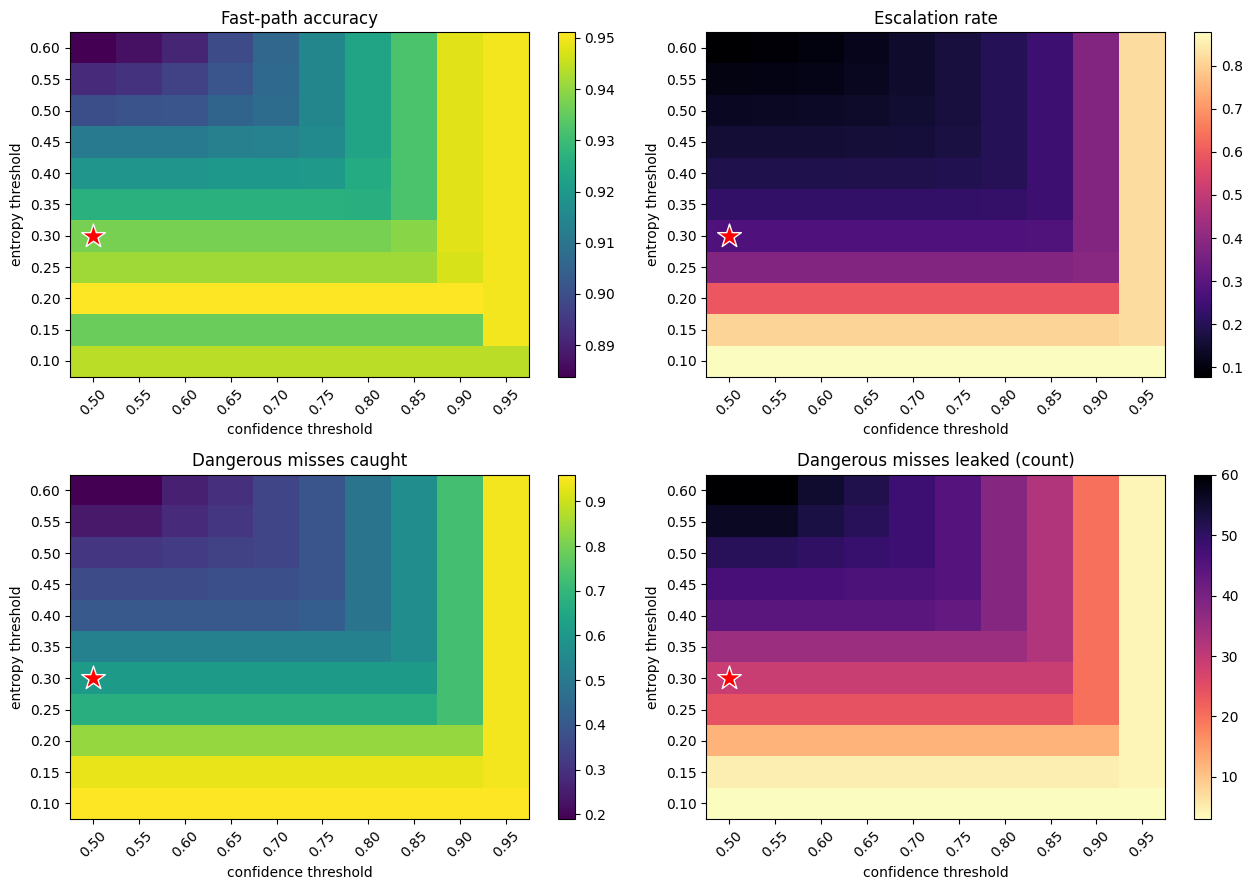

In [ ]:

# ================================================== CELL C: sweep heatmaps
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
panels = [("fastpath_acc", "Fast-path accuracy", "viridis"),
          ("escalation_rate", "Escalation rate", "magma"),
          ("dang_caught", "Dangerous misses caught", "viridis"),
          ("dang_leaked", "Dangerous misses leaked (count)", "magma_r")]

for ax, (col, title, cmap) in zip(axes.ravel(), panels):
    piv = S.pivot_table(index="entropy_thr", columns="conf_thr", values=col)
    im = ax.imshow(piv.values, aspect="auto", origin="lower", cmap=cmap)
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels([f"{c:.2f}" for c in piv.columns], rotation=45)
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels([f"{i:.2f}" for i in piv.index])
    ax.set_xlabel("confidence threshold"); ax.set_ylabel("entropy threshold")
    ax.set_title(title)
    ax.scatter([list(piv.columns).index(CONF_THRESHOLD)],
               [list(piv.index).index(ENTROPY_THRESHOLD)],
               marker="*", s=320, c="red", edgecolors="white", zorder=5)
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig(f"{OUT}/threshold_sweep.png", dpi=140, bbox_inches="tight")
plt.show()
S.to_csv(f"{OUT}/threshold_sweep.csv", index=False)



In [ ]:

# ============================== CELL D: verify on TEST with chosen thresholds
acc_t = (ct >= CONF_THRESHOLD) & (et <= ENTROPY_THRESHOLD)
esc_t = ~acc_t

R = {
    "conf_threshold": CONF_THRESHOLD,
    "entropy_threshold": ENTROPY_THRESHOLD,
    "uncertain_floor": UNCERTAIN_FLOOR,
    "temperature": float(TEMP),
    "test_escalation_rate": float(esc_t.mean()),
    "test_fastpath_acc": float((predt[acc_t] == yt[acc_t]).mean()),
    "test_escalated_acc": float((predt[esc_t] == yt[esc_t]).mean()),
    "test_overall_acc": float((predt == yt).mean()),
    "test_dangerous_total": int(dang_t.sum()),
    "test_dangerous_caught": int((dang_t & esc_t).sum()),
    "test_dangerous_leaked": int((dang_t & acc_t).sum()),
    "compute_saving_vs_always_on": float(1 - esc_t.mean()),
}
R["test_dangerous_caught_pct"] = R["test_dangerous_caught"] / max(R["test_dangerous_total"], 1)

print(f"\n{'='*58}\nTEST SET, chosen thresholds\n{'='*58}")
for k, v in R.items():
    print(f"  {k:32s} {v:.4f}" if isinstance(v, float) else f"  {k:32s} {v}")

print(f"\nHeadline for the demo:")
print(f"  {R['test_escalation_rate']:.0%} of images escalate, so "
      f"{R['compute_saving_vs_always_on']:.0%} never touch the transformer.")
print(f"  Of {R['test_dangerous_total']} malignant lesions Layer 1 called benign, "
      f"the gate catches {R['test_dangerous_caught']} "
      f"({R['test_dangerous_caught_pct']:.0%}).")
print(f"  {R['test_dangerous_leaked']} still slip through — report this honestly, "
      f"it is the real residual risk.")




TEST SET, chosen thresholds
  conf_threshold                   0.5000
  entropy_threshold                0.3000
  uncertain_floor                  0.5000
  temperature                      0.9590
  test_escalation_rate             0.2831
  test_fastpath_acc                0.9371
  test_escalated_acc               0.6103
  test_overall_acc                 0.8446
  test_dangerous_total             75
  test_dangerous_caught            54
  test_dangerous_leaked            21
  compute_saving_vs_always_on      0.7169
  test_dangerous_caught_pct        0.7200

Headline for the demo:
  28% of images escalate, so 72% never touch the transformer.
  Of 75 malignant lesions Layer 1 called benign, the gate catches 54 (72%).
  21 still slip through — report this honestly, it is the real residual risk.


In [ ]:

# ============================================ CELL E: write thresholds.yaml
yaml_txt = f"""# configs/thresholds.yaml
# Derived from the validation sweep, not asserted. See threshold_sweep.csv/png.
# Layer 1: MobileNetV3-Large (fine-tuned), test acc {MB['test_acc']:.4f}, macro-F1 {MB['test_macro_f1']:.4f}

decision_engine:
  conf_threshold: {CONF_THRESHOLD}
  entropy_threshold: {ENTROPY_THRESHOLD}
  uncertain_floor: {UNCERTAIN_FLOOR}

calibration:
  temperature: {TEMP:.4f}
  applied_to: layer1_logits

classes: {CLASSES}
malignant_classes: {MALIGNANT}

# Measured on the held-out test split with the thresholds above.
measured:
  escalation_rate: {R['test_escalation_rate']:.4f}
  fastpath_accuracy: {R['test_fastpath_acc']:.4f}
  escalated_subset_accuracy: {R['test_escalated_acc']:.4f}
  dangerous_misses_total: {R['test_dangerous_total']}
  dangerous_misses_caught: {R['test_dangerous_caught']}
  dangerous_misses_leaked: {R['test_dangerous_leaked']}
"""
os.makedirs(f"{OUT}/configs", exist_ok=True)
open(f"{OUT}/configs/thresholds.yaml", "w").write(yaml_txt)
json.dump(R, open(f"{OUT}/routing_results.json", "w"), indent=2)
print("\n" + yaml_txt)




# configs/thresholds.yaml
# Derived from the validation sweep, not asserted. See threshold_sweep.csv/png.
# Layer 1: MobileNetV3-Large (fine-tuned), test acc 0.8446, macro-F1 0.7077

decision_engine:
  conf_threshold: 0.5
  entropy_threshold: 0.3
  uncertain_floor: 0.5

calibration:
  temperature: 0.9590
  applied_to: layer1_logits

classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
malignant_classes: ['mel', 'bcc', 'akiec']

# Measured on the held-out test split with the thresholds above.
measured:
  escalation_rate: 0.2831
  fastpath_accuracy: 0.9371
  escalated_subset_accuracy: 0.6103
  dangerous_misses_total: 75
  dangerous_misses_caught: 54
  dangerous_misses_leaked: 21



In [ ]:

# ================== CELL F: the hard subset for Kashish to train Layer 2 on
hard = pd.DataFrame({
    "image_id": te.image_id.values,
    "true": [CLASSES[i] for i in yt],
    "pred": [CLASSES[i] for i in predt],
    "confidence": ct, "entropy": et,
    "escalated": esc_t, "dangerous_miss": dang_t,
})
hard.to_csv(f"{OUT}/test_routing_detail.csv", index=False)

# Same thing over the TRAIN split — this is the low-confidence subset that
# Layer 2 (RT-DETR) actually gets fine-tuned on, per blueprint Section 7.2.
from torch.utils.data import DataLoader as _DL
dl_tr_eval = _DL(HAM(tr, eval_tf), 64, num_workers=2, pin_memory=True)
Ltr, ytr_ = logits_for(dl_tr_eval)
_, ctr, etr = conf_entropy(Ltr, TEMP)
esc_tr = ~((ctr >= CONF_THRESHOLD) & (etr <= ENTROPY_THRESHOLD))

pd.DataFrame({"image_id": tr.image_id.values, "dx": tr.dx.values,
              "confidence": ctr, "entropy": etr, "escalated": esc_tr}) \
  .to_csv(f"{OUT}/layer2_train_subset.csv", index=False)
print(f"\nLayer 2 training subset: {esc_tr.sum()} / {len(esc_tr)} train images "
      f"({esc_tr.mean():.1%}) fall below the gate -> layer2_train_subset.csv")


Layer 2 training subset: 478 / 7116 train images (6.7%) fall below the gate -> layer2_train_subset.csv


In [ ]:
import os, torch
p = f"{OUT}/baseline_mobilenetv3.pt"
print(os.path.exists(p), os.path.getsize(p)/1e6, "MB")
c = torch.load(p, map_location="cpu", weights_only=False)
print(c["metrics"], c["temperature"], c["classes"])

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/amsdds/mobilenetv4299/baseline_mobilenetv3.pt'

In [ ]:
import shutil
shutil.copy(f"{OUT}/baseline_mobilenetv3.pt", f"{OUT}/layer1_mobilenetv3_best.pt")

In [ ]:
print("fitted T:", TEMP)  # you got 1.015 — barely above 1, i.e. almost no scaling applied